In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "zara2099/e-commerce-personalized-recommendation-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 34.2k/34.2k [00:00<00:00, 2.50MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/zara2099/e-commerce-personalized-recommendation-dataset/versions/1


In [3]:
csv_files = glob.glob(os.path.join(path, "*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

CSV files found:
/root/.cache/kagglehub/datasets/zara2099/e-commerce-personalized-recommendation-dataset/versions/1/Ecommerce_Personalized_Recommendation_Dataset.csv


In [4]:
df = pd.read_csv(csv_files[0])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 22)


,User_ID,Product_ID,Category,Brand,User_Age,User_Gender,User_Location,Device_Type,Session_Duration_Min,Pages_Viewed,...,User_Rating,Product_Price,Discount_Applied,Graph_Similarity_Score,Federated_Cluster_ID,Local_Model_Accuracy,Global_Model_Weight,Personalization_Factor,Purchase_Probability,Recommended
0,U0103,P0049,Books,BrandE,35,Female,Rural,Desktop,57.36,14,...,2,268.02,1,0.925,2,0.833,0.971,0.800,0.632,1
1,U0271,P0173,Sports,BrandD,21,Male,Suburban,Mobile,15.17,3,...,2,104.62,0,0.918,5,0.845,0.713,0.599,0.692,1
2,U0107,P0030,Sports,BrandD,18,Female,Urban,Tablet,20.09,5,...,4,145.91,1,0.303,4,0.836,0.384,0.683,0.604,1
3,U0072,P0144,Clothing,BrandC,18,Male,Rural,Mobile,11.84,7,...,3,383.75,0,0.592,1,0.735,0.760,0.394,0.624,1
4,U0189,P0168,Electronics,BrandE,43,Male,Urban,Mobile,35.04,1,...,1,237.82,0,0.960,9,0.839,0.397,0.245,0.569,0


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 1000
Number of columns: 22

Column names:
['User_ID', 'Product_ID', 'Category', 'Brand', 'User_Age', 'User_Gender', 'User_Location', 'Device_Type', 'Session_Duration_Min', 'Pages_Viewed', 'Time_of_Day', 'Previous_Purchases', 'User_Rating', 'Product_Price', 'Discount_Applied', 'Graph_Similarity_Score', 'Federated_Cluster_ID', 'Local_Model_Accuracy', 'Global_Model_Weight', 'Personalization_Factor', 'Purchase_Probability', 'Recommended']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   User_ID                 1000 non-null   object 
 1   Product_ID              1000 non-null   object 
 2   Category                1000 non-null   object 
 3   Brand                   1000 non-null   object 
 4   User_Age                1000 non-null   int64  
 5   User_Gender             1000 non-null   object 
 6   User_Location           1000 non-null   object 
 7   Device_Type             1000 non-null   object 
 8   Session_Duration_Min    1000 non-null   float64
 9   Pages_Viewed            1000 non-null   int64  
 10  Time_of_Day             1000 non-null   object 
 11  Previous_Purchases      1000 non-null   int64  
 12  User_Rating             1000 non-null   int64  
 13  Product_Price           1000 non-null   float64
 14  Discount_Applied        1000 non-null   i

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,1000,285,U0099,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_ID,1000,199,P0029,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1000,7,Books,161,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Brand,1000,5,BrandD,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_Age,1000.0,NaN,NaN,NaN,40.819,13.60078,18.0,29.0,40.0,53.0,64.0
User_Gender,1000,3,Male,469,NaN,NaN,NaN,NaN,NaN,NaN,NaN
User_Location,1000,3,Urban,515,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Device_Type,1000,3,Mobile,600,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Session_Duration_Min,1000.0,NaN,NaN,NaN,29.80839,16.750801,1.01,15.44,29.22,44.045,59.95
Pages_Viewed,1000.0,NaN,NaN,NaN,10.17,5.553372,1.0,5.0,10.0,15.0,19.0


In [8]:
missing = df.isnull().sum()

print("Missing values:")
print(missing[missing > 0])

Missing values:
Series([], dtype: int64)


In [9]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [11]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000, 22)


In [12]:
for col in df.columns:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    print(df[col].unique()[:10])


User_ID
Unique values: 285
['U0103' 'U0271' 'U0107' 'U0072' 'U0189' 'U0021' 'U0122' 'U0215' 'U0088'
 'U0100']

Product_ID
Unique values: 199
['P0049' 'P0173' 'P0030' 'P0144' 'P0168' 'P0019' 'P0018' 'P0001' 'P0078'
 'P0115']

Category
Unique values: 7
['Books' 'Sports' 'Clothing' 'Electronics' 'Toys' 'Home & Kitchen'
 'Beauty']

Brand
Unique values: 5
['BrandE' 'BrandD' 'BrandC' 'BrandA' 'BrandB']

User_Age
Unique values: 47
[35 21 18 43 62 37 40 27 28 58]

User_Gender
Unique values: 3
['Female' 'Male' 'Other']

User_Location
Unique values: 3
['Rural' 'Suburban' 'Urban']

Device_Type
Unique values: 3
['Desktop' 'Mobile' 'Tablet']

Session_Duration_Min
Unique values: 928
[57.36 15.17 20.09 11.84 35.04 10.14 22.02 42.12 34.05 23.8 ]

Pages_Viewed
Unique values: 19
[14  3  5  7  1 12 11  8  6  2]

Time_of_Day
Unique values: 4
['Evening' 'Night' 'Afternoon' 'Morning']

Previous_Purchases
Unique values: 50
[ 5 41 39 30 16 24 31 11 48 12]

User_Rating
Unique values: 5
[2 4 3 1 5]

Product_Pr

In [13]:
category_counts = df["Category"].value_counts()

print(category_counts)

Category
Books             161
Sports            154
Clothing          150
Beauty            145
Toys              139
Electronics       132
Home & Kitchen    119
Name: count, dtype: int64


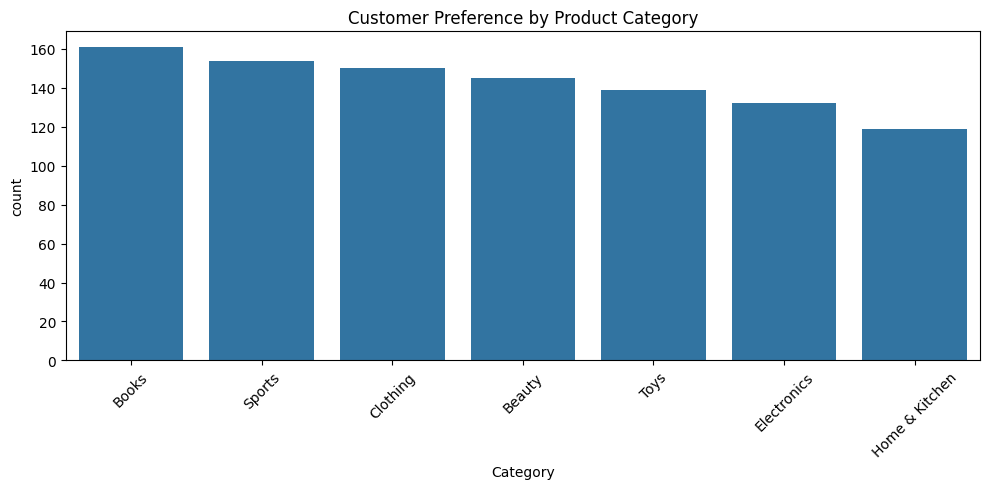

In [14]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Category",
    order=df["Category"].value_counts().index
)

plt.title("Customer Preference by Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

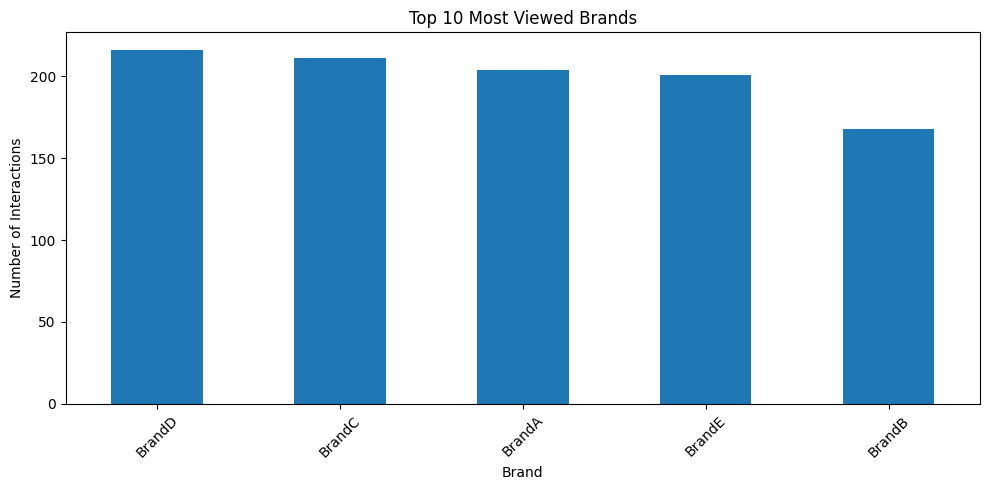

In [15]:
brand_counts = df["Brand"].value_counts().head(10)

plt.figure(figsize=(10, 5))

brand_counts.plot(kind="bar")

plt.title("Top 10 Most Viewed Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Interactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

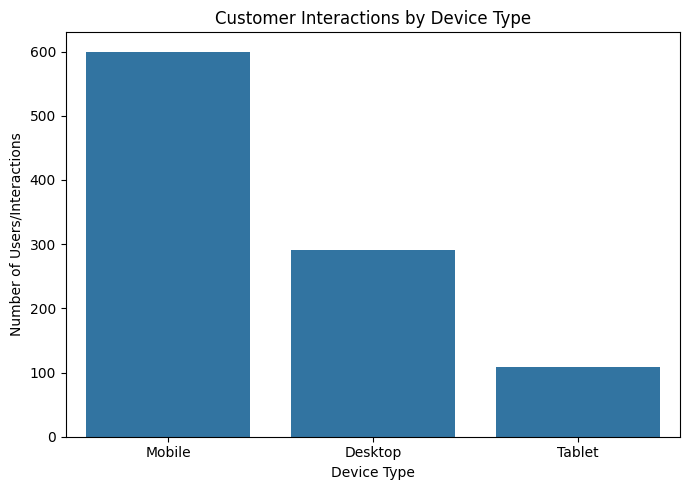

In [16]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Device_Type",
    order=df["Device_Type"].value_counts().index
)

plt.title("Customer Interactions by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Number of Users/Interactions")

plt.tight_layout()
plt.show()

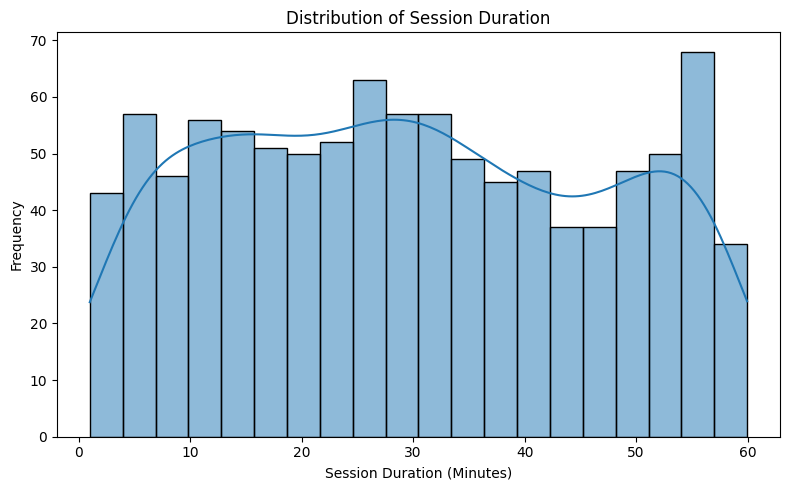

In [17]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Session_Duration_Min"],
    bins=20,
    kde=True
)

plt.title("Distribution of Session Duration")
plt.xlabel("Session Duration (Minutes)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

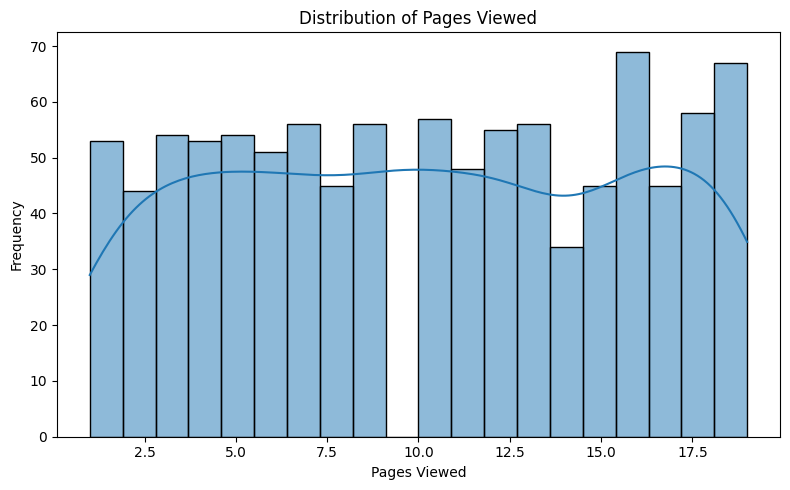

In [18]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Pages_Viewed"],
    bins=20,
    kde=True
)

plt.title("Distribution of Pages Viewed")
plt.xlabel("Pages Viewed")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

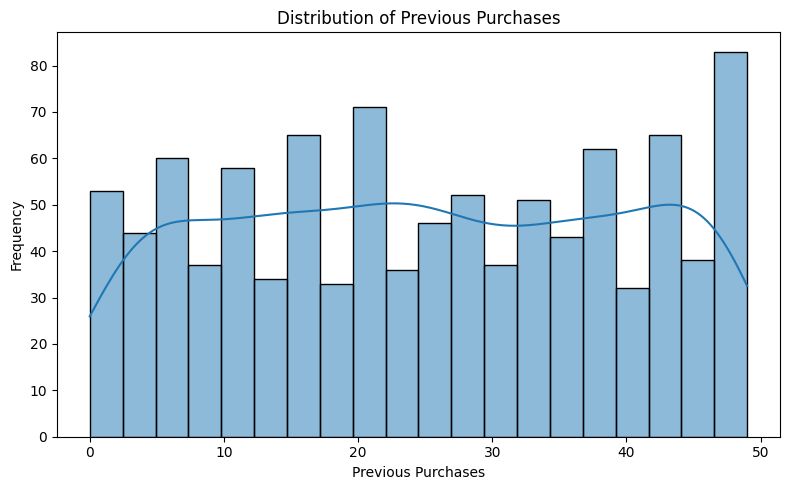

In [19]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Previous_Purchases"],
    bins=20,
    kde=True
)

plt.title("Distribution of Previous Purchases")
plt.xlabel("Previous Purchases")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

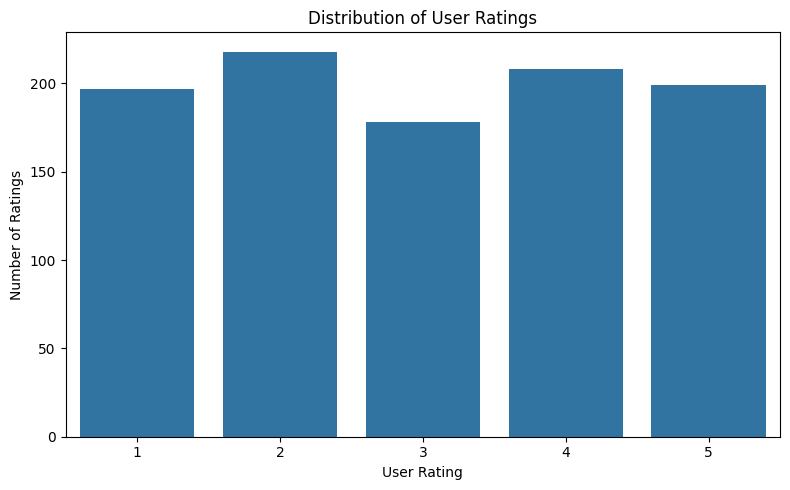

In [20]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="User_Rating"
)

plt.title("Distribution of User Ratings")
plt.xlabel("User Rating")
plt.ylabel("Number of Ratings")

plt.tight_layout()
plt.show()

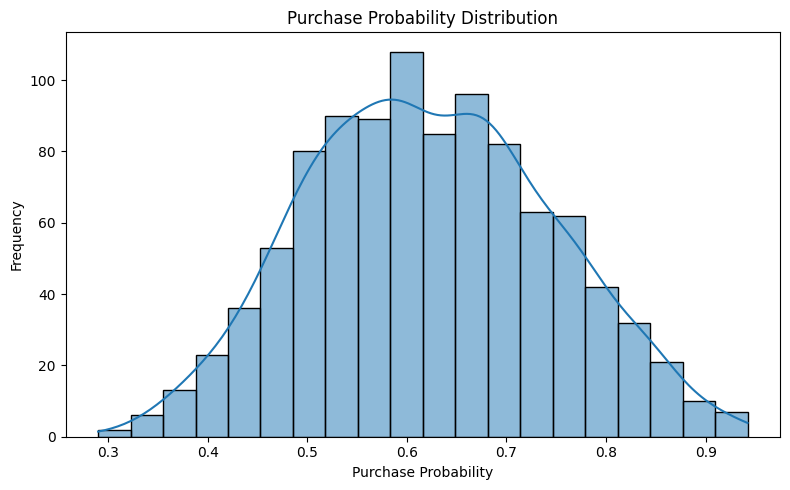

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Purchase_Probability"],
    bins=20,
    kde=True
)

plt.title("Purchase Probability Distribution")
plt.xlabel("Purchase Probability")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [22]:
print(df["Recommended"].value_counts())

Recommended
1    545
0    455
Name: count, dtype: int64


In [23]:
print(
    df["Recommended"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Recommended
1    54.5
0    45.5
Name: proportion, dtype: float64


In [24]:
print(
    df["Recommended"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Recommended
1    54.5
0    45.5
Name: proportion, dtype: float64


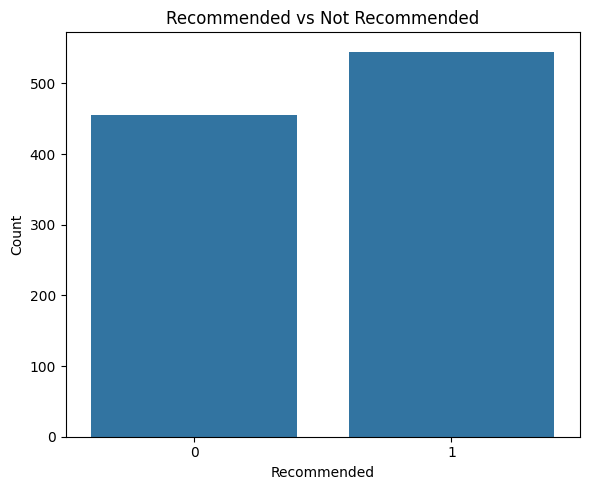

In [25]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="Recommended"
)

plt.title("Recommended vs Not Recommended")
plt.xlabel("Recommended")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [26]:
category_recommendation = pd.crosstab(
    df["Category"],
    df["Recommended"],
    normalize="index"
) * 100

print(category_recommendation.round(2))

Recommended         0      1
Category                    
Beauty          41.38  58.62
Books           44.72  55.28
Clothing        44.67  55.33
Electronics     50.00  50.00
Home & Kitchen  47.90  52.10
Sports          50.65  49.35
Toys            39.57  60.43


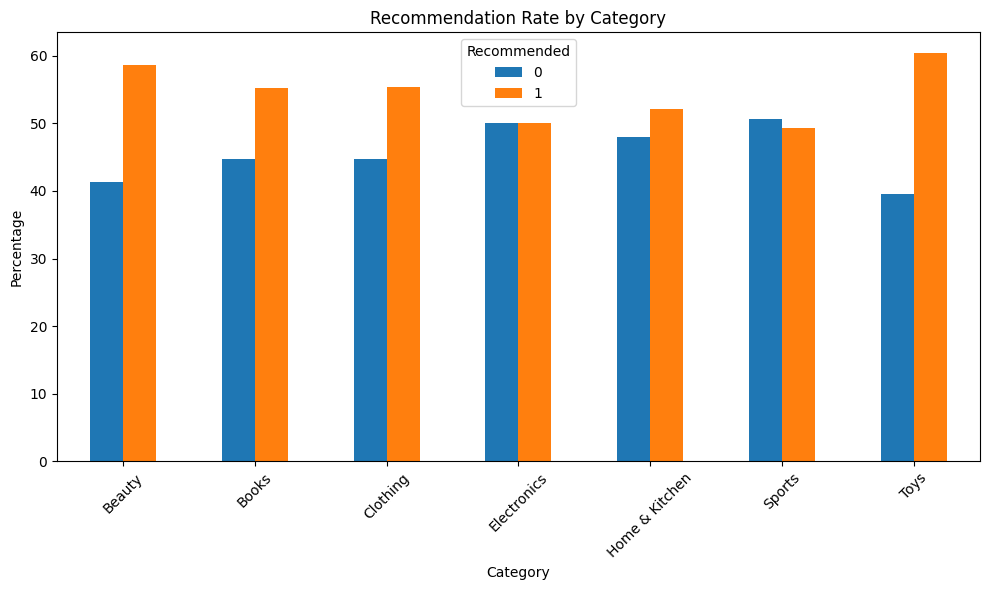

In [27]:
category_recommendation.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Recommendation Rate by Category")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()